# CHB-MIT eeg dataset seizure detection demo
This notebook is demo for seizure detection using CHB-MIT eeg dataset.  
In this notebook, deep learning model with 2d CNN is buit for seizure detection.  
Keras is used for deep learning platform.  

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
'''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

In [2]:
# install library for reading edf files and visualization of NN model

#!pip install pyedflib visualkeras

In [3]:
#import numpy as np
import matplotlib.pyplot as plt
#import pyedflib
import wfdb
import glob
import random
import gc
import mne
from scipy.signal import find_peaks
import re
import tqdm
import logging

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Data manipulation
First of all, let's create training data.  
1. Patients are divided into training and test group.
2. EEG data of 8 sec with labels are extracted form training group.
3. Preprocessing: EEG data, originally 256 Hz sampling rate, are resampled to 128 Hz.
4. EEG data is divided into test data and validation data. The validation data is used for early stopping.

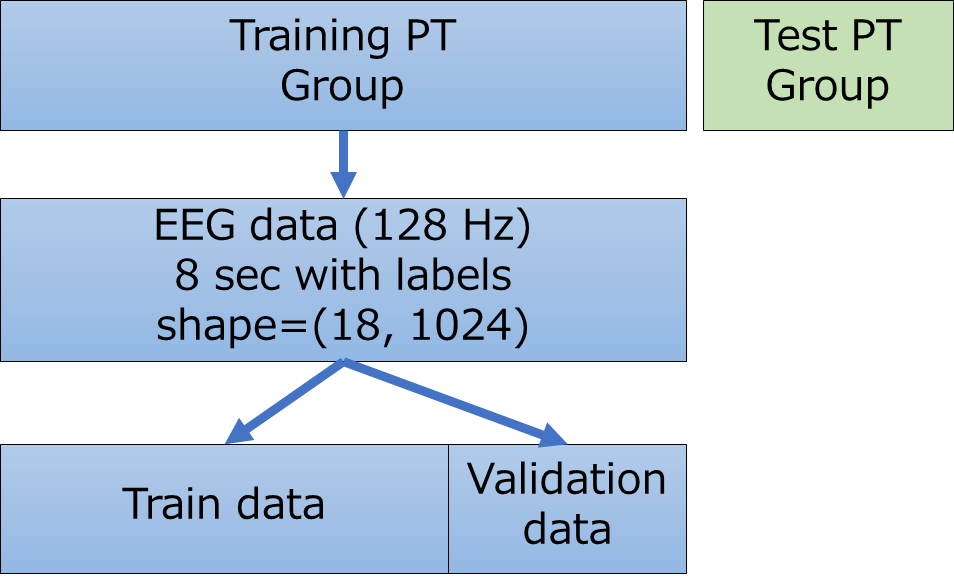

#### Channels are of bipolar montage. EEG waves are lined up as listed below.

In [4]:
ch_labels = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3','P3-O1',
             'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
             'FZ-CZ', 'CZ-PZ']

#### Patients folders are placed in /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/.
#### Patients' ID are extracted by folder names.

In [5]:
path2pt = '/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0'

folders = sorted(glob.glob(path2pt+'/*/'))
n_patient = [m[-2:] for m in [l.rsplit('/', 2)[-2] for l in folders]]

print(*n_patient)

01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24


#### Patients are randomly divided into training and test groups.

In [6]:
random.seed(2023)

ratio_train = 0.8
train_patient_str = sorted(random.sample(n_patient, round(ratio_train*len(n_patient))))
test_patient_str = sorted([l for l in n_patient if l not in train_patient_str])
print('Train PT: ', *train_patient_str)
print('Test PT: ', *test_patient_str)

Train PT:  02 03 04 05 06 09 11 12 13 14 15 16 17 18 19 20 21 23 24
Test PT:  01 07 08 10 22


In [7]:
# file names for training and test data

files_train = []
for l in train_patient_str:
    files_train = files_train + glob.glob(path2pt+'/chb{}/*.edf'.format(l))

files_test = []
for l in test_patient_str:
    files_test = files_test + glob.glob(path2pt+'/chb{}/*.edf'.format(l))

In [8]:
len(files_train), len(files_test)

(549, 137)

## Signal Extraction for training data
Each 8 second signals of 18 channels are extracted, sliding forward by 4 seconds.  
Each set of signals are labeled with the ratio of seizure in the time window. i.e. a set of signals are labeled 1.0 if it is in the middle of seizure.  

To save time, already extracted signals and labels are located in /kaggle/input/mit-chb-processed, and they will be loaded.  
You may try extracting by deleteing the processed data.

In [9]:
mne.set_log_level(verbose='ERROR')

In [10]:
logger = logging.getLogger(__name__)
fh = logging.FileHandler('read_files.log')
logger.addHandler(fh)

time_window = 8
time_step = 4

if os.path.exists('/kaggle/input/mit-chb-processed/signal_samples.npy')&os.path.exists('/kaggle/input/mit-chb-processed/is_sz.npy'):
    array_signals=np.load('/kaggle/input/mit-chb-processed/signal_samples.npy')
    array_is_sz=np.load('/kaggle/input/mit-chb-processed/is_sz.npy')
else:
    p = 0.01  
    counter = 0
    for temp_f in files_train:
        temp_edf =  mne.io.read_raw_edf(temp_f)
        temp_labels = temp_edf.ch_names
        if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
            time_window = 8
            time_step = 4
            fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
            step_window = time_window*fs
            step = time_step*fs
            
            temp_is_sz = np.zeros((temp_edf.n_times,))
            if os.path.exists(temp_f+'.seizures'):
                temp_annotation = wfdb.rdann(temp_f, 'seizures')
                for i in range(int(temp_annotation.sample.size/2)):
                    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
            temp_len = temp_edf.n_times
            
            temp_is_sz_ind = np.array(
                [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
            )

            temp_0_sample_size = round(p*np.where(temp_is_sz_ind==0)[0].size)
            temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size

            counter = counter + temp_0_sample_size + temp_1_sample_size
        temp_edf.close()

    array_signals = np.zeros((counter, len(ch_labels), step_window), dtype=np.float32)
    array_is_sz = np.zeros(counter, dtype=bool)

    counter = 0
    for n, temp_f in enumerate(tqdm.tqdm(files_train)):
        to_log = 'No. {}: Reading. '.format(n)
        temp_edf =  mne.io.read_raw_edf(temp_f)
        temp_labels = temp_edf.ch_names
        n_label_match = sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])
        if n_label_match==len(ch_labels):
            ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
            temp_edf.rename_channels(ch_mapping)
            #temp_edf = temp_edf.pick(ch_labels)

            temp_is_sz = np.zeros((temp_edf.n_times,))
            temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

            if os.path.exists(temp_f+'.seizures'):
                to_log = to_log+'sz exists.'
                temp_annotation = wfdb.rdann(temp_f, 'seizures')
                for i in range(int(temp_annotation.sample.size/2)):
                    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
            else:
                to_log = to_log+'No sz.'

            temp_len = temp_edf.n_times

            time_window = 8
            time_step = 4
            fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
            step_window = time_window*fs
            step = time_step*fs

            temp_is_sz_ind = np.array(
                [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
            )
            del temp_is_sz

            temp_0_sample_size = round(p*np.where(temp_is_sz_ind==0)[0].size)
            temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size

            # sz data
            temp_ind = list(np.where(temp_is_sz_ind>0)[0])
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = True
                counter = counter+1

            # no sz data
            temp_ind = random.sample(list(np.where(temp_is_sz_ind==0)[0]), temp_0_sample_size)
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = False
                counter = counter+1

            to_log += '{} signals added: {} w/o sz, {} w/ sz.'.format(
                temp_0_sample_size+temp_1_sample_size, temp_0_sample_size, temp_1_sample_size
            )

        else:
            to_log += 'Not appropriate channel labels. Reading skipped.'.format(n)
        
        logger.info(to_log)
        temp_edf.close()

        if n%10==0:
            gc.collect()
    gc.collect()
    
    np.save('signal_samples', array_signals)
    np.save('is_sz', array_is_sz)

In [11]:
array_signals.shape

(9505, 18, 2048)

## preprocess
#### Signals frequencies are originally 256 Hz, but resampled to 128 Hz for simplification of the data.

In [12]:
array_signals = array_signals[:, :, ::2]

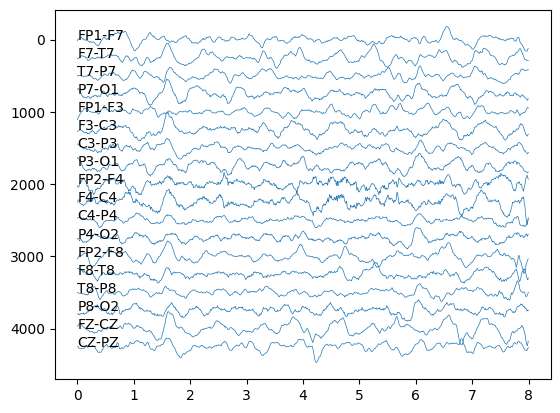

In [13]:
# show a sample of extracted signals (the last one)

vertical_width = 250
signals = array_signals[-1, :, :]
fs = 128

fig, ax = plt.subplots()
for i in range(signals.shape[0]):
    ax.plot(np.arange(signals.shape[-1])/fs, signals[i, :]+i*vertical_width, linewidth=0.5, color='tab:blue')
    ax.annotate(ch_labels[i], xy=(0, i*vertical_width))
ax.invert_yaxis()
plt.show()

In [14]:
# Checking how much of signals have seizure inside.

array_n = np.where(array_is_sz>.0)[0]
print('Number of all the extracted signals: {}'.format(array_is_sz.size))
print('Number of signals with seizures: {}'.format(array_n.size))
print('Ratio of signals with seizures: {:.3f}'.format(array_n.size/array_is_sz.size))

Number of all the extracted signals: 9505
Number of signals with seizures: 2581
Ratio of signals with seizures: 0.272


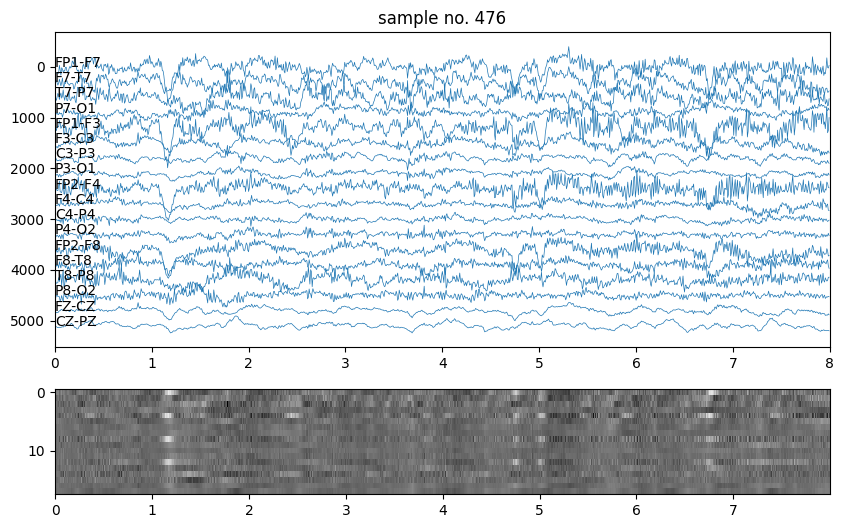

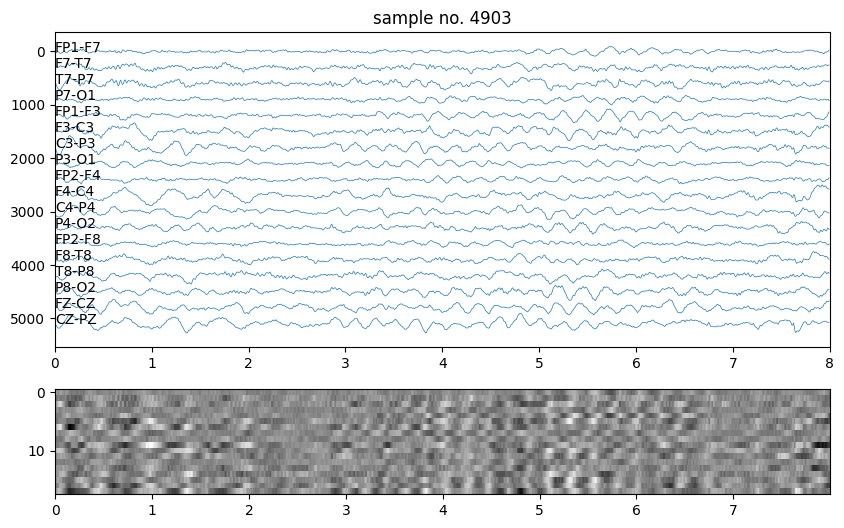

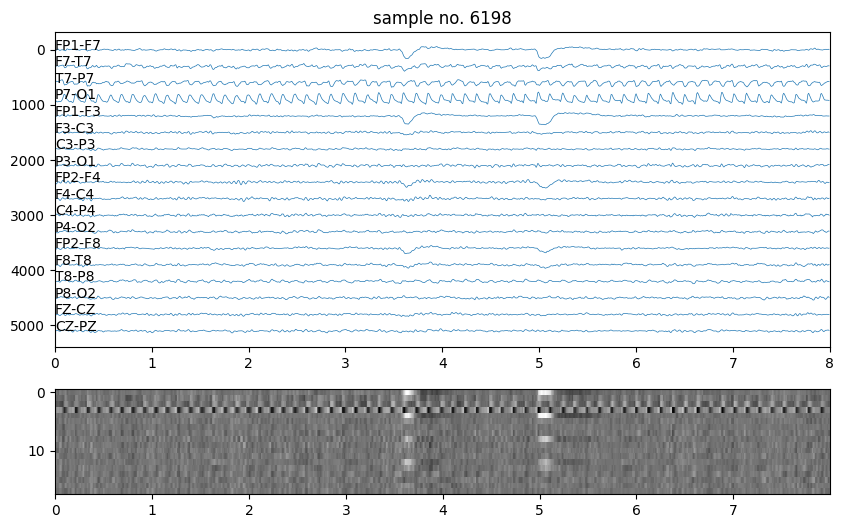

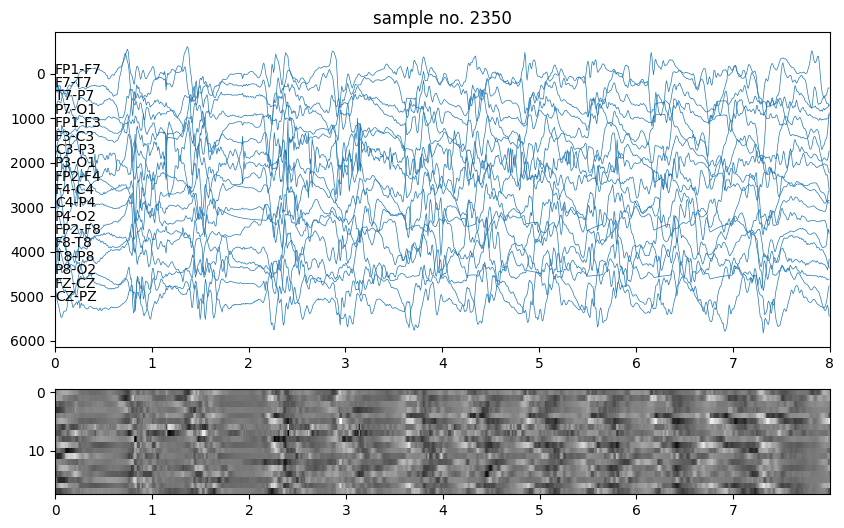

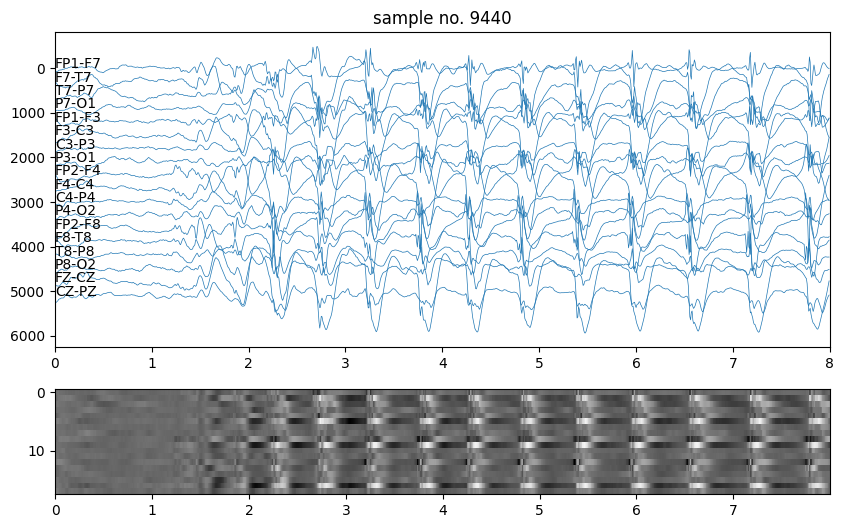

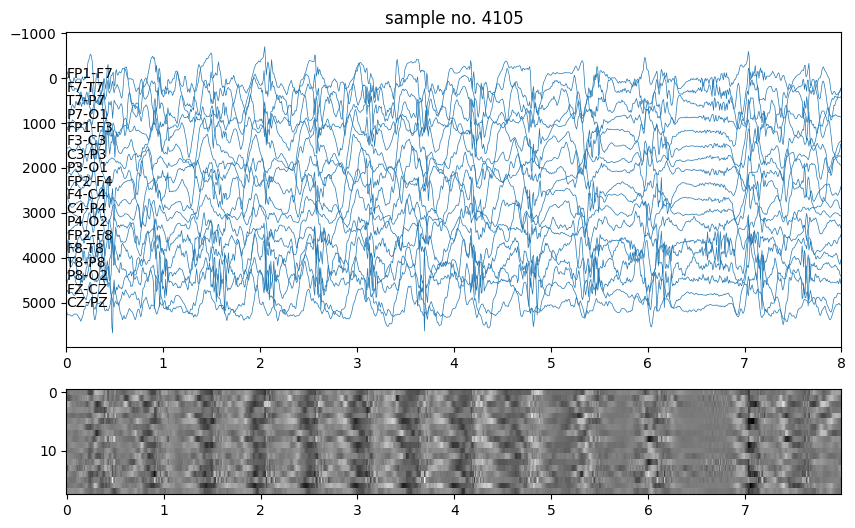

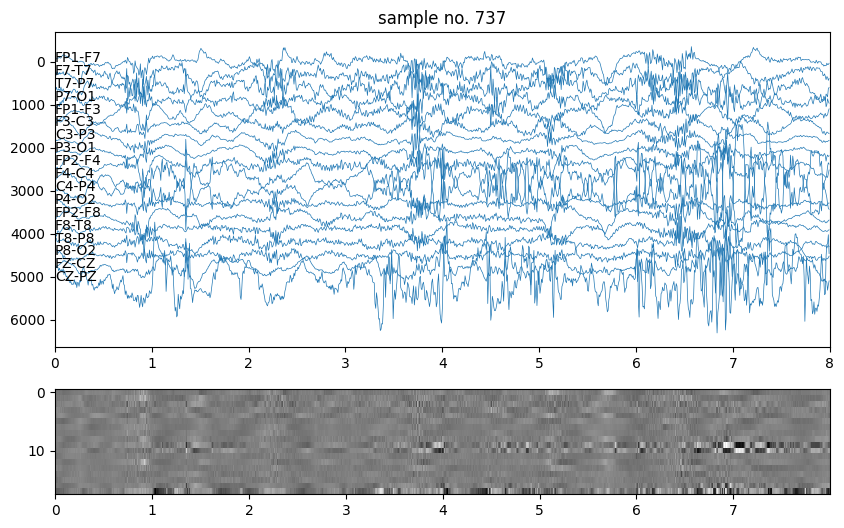

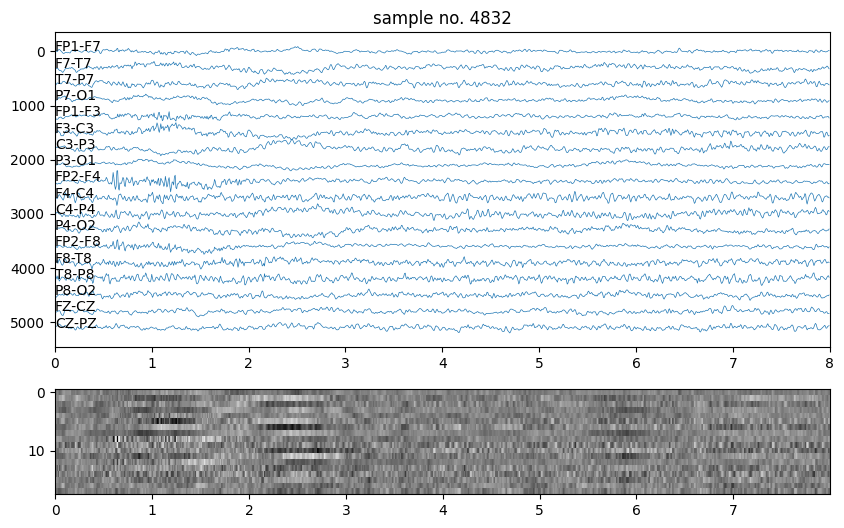

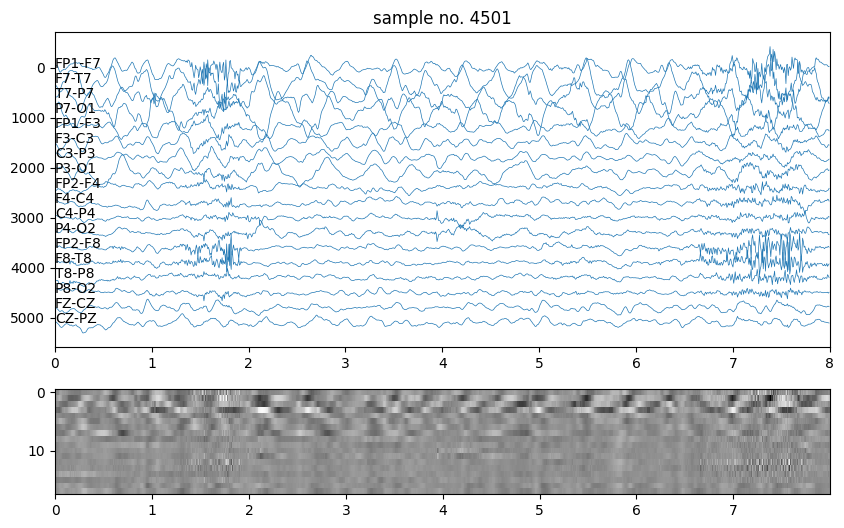

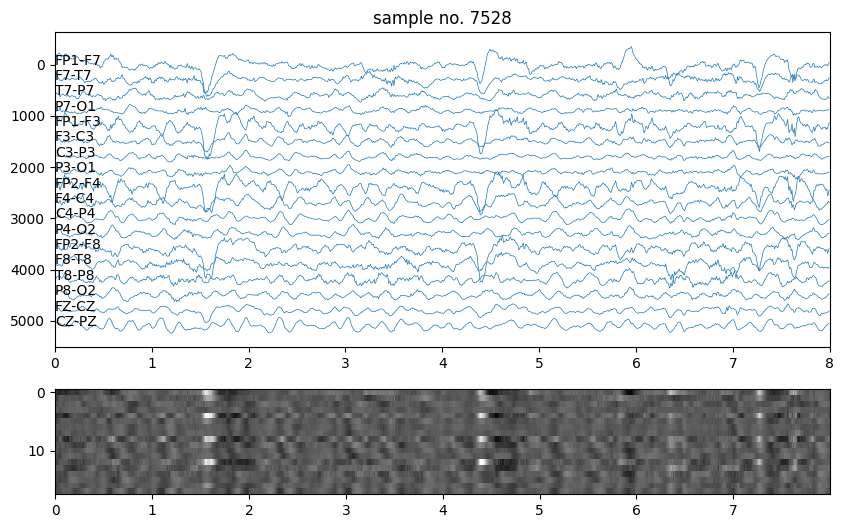

In [15]:
# Let's see samples with seizures.

for n in random.sample(list(array_n), 10):

    vertical_width = 300
    temp_signals = array_signals[n, :, :]
    fs = 128

    fig, ax = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})
    for i in range(temp_signals.shape[0]):
        ax[0].plot(np.arange(temp_signals.shape[-1])/fs, temp_signals[i, :]+i*vertical_width, linewidth=0.5, color='tab:blue')
        ax[0].annotate(ch_labels[i], xy=(0, i*vertical_width))
    ax[0].invert_yaxis()
    ax[0].set_xlim(0, 8)
    ax[0].set_title('sample no. {}'.format(n))
    
    ax[1].pcolormesh(np.arange(temp_signals.shape[-1])/fs, np.arange(len(ch_labels)), temp_signals[:, :], cmap='gray')
    ax[1].invert_yaxis()
    
    plt.show()

In [16]:
from sklearn import model_selection

In [17]:
# CNN will be used. Channel dimension is added.
array_signals = array_signals[:, :, :, np.newaxis]

array_signals.shape

(9505, 18, 1024, 1)

In [18]:
# splitting training data into training & validation data.

X_train, X_val, y_train, y_val = model_selection.train_test_split(
    array_signals, array_is_sz, test_size=0.3,
    stratify=(array_is_sz>0))

del array_signals, array_is_sz

# Building and training deep learning models with Keras
We will make deep learning model with 2D-CNN and FC.  
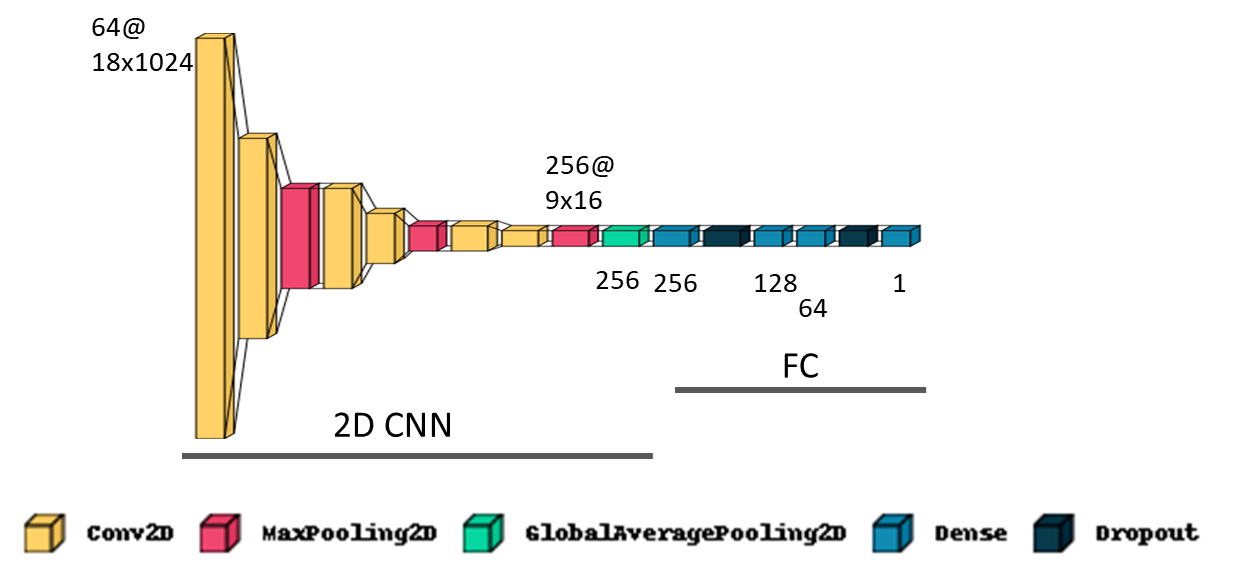

In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

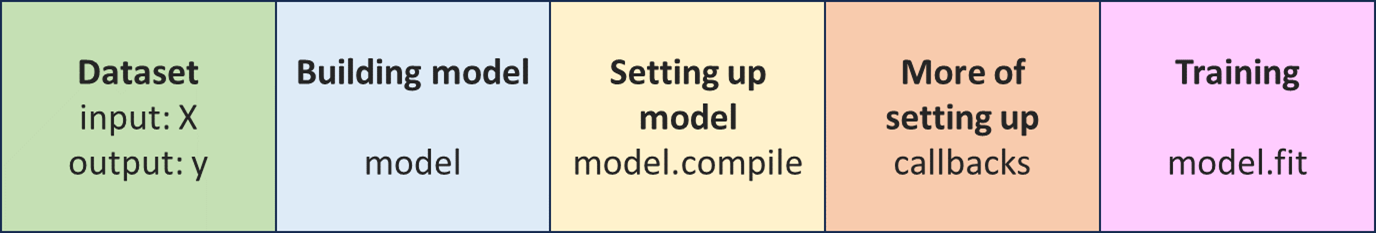

In [20]:
## deep learning model

model = keras.models.Sequential()

model.add(layers.Conv2D(filters=64, kernel_size=(2, 4), padding='same', activation='relu', input_shape=X_train.shape[1:]))
model.add(layers.Conv2D(filters=64, kernel_size=(2, 4), strides=(1, 2),padding='same', activation='relu'))
model.add(layers.MaxPooling2D((1, 2)))

model.add(layers.Conv2D(filters=128, kernel_size=(2, 4), padding='same', activation='relu'))
model.add(layers.Conv2D(filters=128, kernel_size=(2, 4), strides=(1, 2), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(filters=256, kernel_size=(4, 4), padding='same', activation='relu'))
model.add(layers.Conv2D(filters=256, kernel_size=(4, 4), strides=(1, 2), padding='same', activation='relu'))
model.add(layers.MaxPooling2D((1, 2)))

model.add(layers.GlobalAveragePooling2D())
#model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1, activation='sigmoid'))

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 18, 1024, 64)      576       
                                                                 
 conv2d_1 (Conv2D)           (None, 18, 512, 64)       32832     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 18, 256, 64)      0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 18, 256, 128)      65664     
                                                                 
 conv2d_3 (Conv2D)           (None, 18, 128, 128)      131200    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 9, 64, 128)       0         
 2D)                                                    

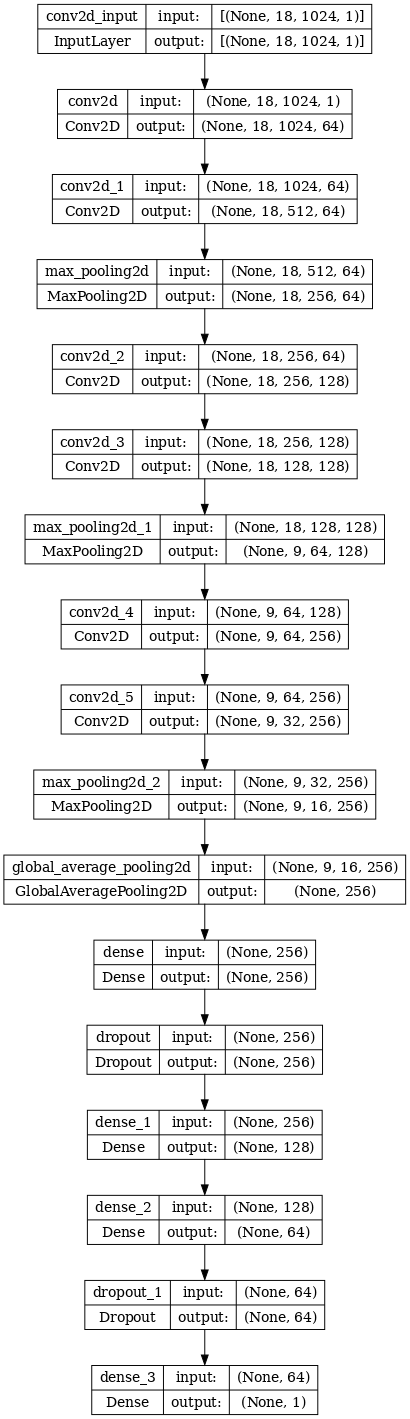

In [22]:
from keras.utils import plot_model
#plot_model(model, show_shapes=True, to_file='model.png')
plot_model(model, show_shapes=True, dpi=70)

In [23]:
#import visualkeras
#visualkeras.layered_view(model, scale_xy=0.5, legend=True)

### Setup for training
### At least, **OPTIMIZER** and **LOSS** has to be set.

In [24]:
LEARNING_RATE = 1e-4
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(optimizer=OPTIMIZER, loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
# callbacks
VERBOSE=1
#lr = ReduceLROnPlateau(monitor='val_loss', factor=0.75, patience=5, verbose=VERBOSE, min_le=1e-8)
es = EarlyStopping(monitor='val_loss', patience=20, verbose=VERBOSE, mode='auto', restore_best_weights=True)

callbacks = [es]

In [26]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((6653, 18, 1024, 1), (6653,), (2852, 18, 1024, 1), (2852,))

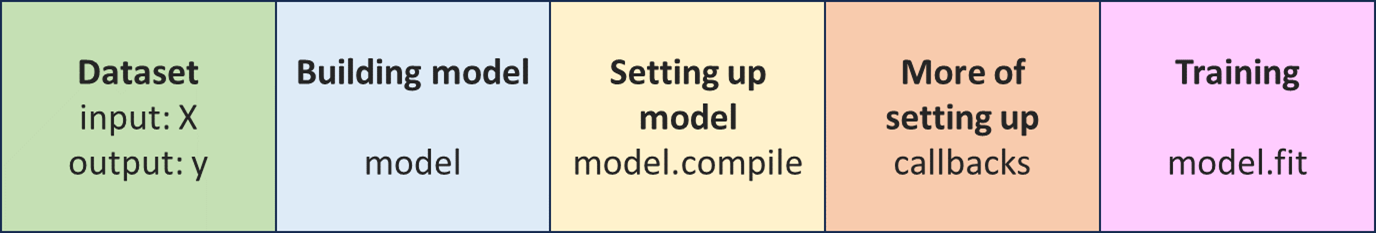

In [27]:
hist = model.fit(
    x=X_train, y=y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=256,
    callbacks=callbacks
)

Epoch 1/200
26/26 [==============================] - 53s 1s/step - loss: 0.7030 - accuracy: 0.6493 - val_loss: 0.6747 - val_accuracy: 0.7286
Epoch 2/200
26/26 [==============================] - 29s 1s/step - loss: 0.6712 - accuracy: 0.7225 - val_loss: 0.6487 - val_accuracy: 0.7290
Epoch 3/200
26/26 [==============================] - 31s 1s/step - loss: 0.6273 - accuracy: 0.7309 - val_loss: 0.6215 - val_accuracy: 0.6760
Epoch 4/200
26/26 [==============================] - 30s 1s/step - loss: 0.5776 - accuracy: 0.7506 - val_loss: 0.5603 - val_accuracy: 0.7616
Epoch 5/200
26/26 [==============================] - 30s 1s/step - loss: 0.5283 - accuracy: 0.7792 - val_loss: 0.5268 - val_accuracy: 0.7809
Epoch 6/200
26/26 [==============================] - 30s 1s/step - loss: 0.5104 - accuracy: 0.7796 - val_loss: 0.5231 - val_accuracy: 0.7472
Epoch 7/200
26/26 [==============================] - 30s 1s/step - loss: 0.4860 - accuracy: 0.7933 - val_loss: 0.5072 - val_accuracy: 0.7598
Epoch 8/200
2

In [28]:
model.save('CHB_MIT_sz_detec_demo.h5')

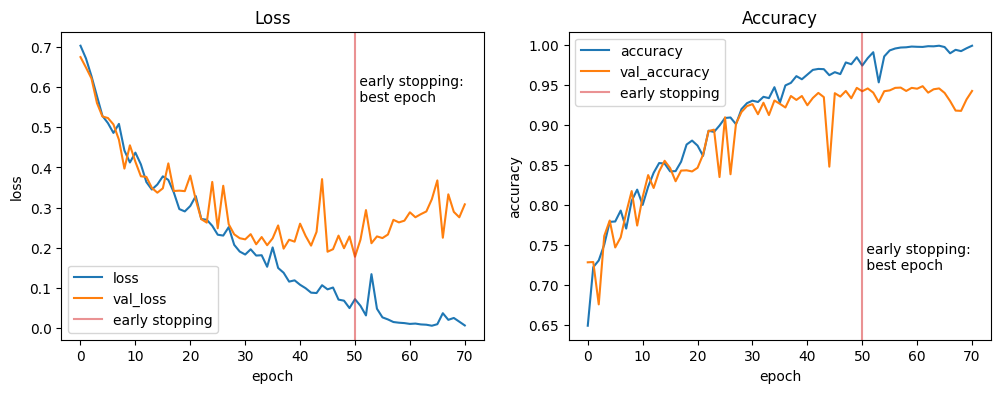

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist.history['loss'], label='loss')
ax[0].plot(hist.history['val_loss'], label='val_loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].axvline(x=es.best_epoch, label='early stopping', color='tab:red', alpha=0.5)
r = .2
temp_y = r*min(hist.history['loss'])+(1-r)*max(hist.history['loss'])
ax[0].annotate(' early stopping:\n best epoch', xy=(es.best_epoch, temp_y))
ax[0].set_title('Loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='accuracy')
ax[1].plot(hist.history['val_accuracy'], label='val_accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
r = .8
temp_y = r*min(hist.history['accuracy'])+(1-r)*max(hist.history['accuracy'])
ax[1].axvline(x=es.best_epoch, label='early stopping', color='tab:red', alpha=0.5)
ax[1].annotate(' early stopping:\n best epoch', xy=(es.best_epoch, temp_y))
ax[1].set_title('Accuracy')
ax[1].legend()

plt.show()

In [30]:
# You may just load model without training. To do so, just run the code below by omitting '#'.

#model = keras.models.load_model('/kaggle/input/mit-chb-processed/CHB_MIT_sz_detec_demo.h5')

# Evaluating the model with test data

## Evaluation of the model by scores and ROC

In [31]:
def sampling_data_pred(f, verbose=True):
    list_signals = []
    list_is_sz = []
    #n_sample = 40
    if verbose==True:
        print('{}: Reading. '.format(f))
    temp_edf =  mne.io.read_raw_edf(f)
    temp_labels = temp_edf.ch_names
    if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
        ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
        temp_edf.rename_channels(ch_mapping)
        #temp_edf = temp_edf.pick(ch_labels)

        temp_is_sz = np.zeros((temp_edf.n_times,))
        temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

        if os.path.exists(f+'.seizures'):
            if verbose==True:
                print('sz exists.', end=' ')
            temp_annotation = wfdb.rdann(f, 'seizures')
            for i in range(int(temp_annotation.sample.size/2)):
                temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
        #else:
            #print('No sz.', end=' ')

        temp_len = temp_edf.n_times

        time_window = 8
        time_step = 4
        fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
        step_window = time_window*fs
        step = time_step*fs

        # sampling all signals
        temp_array_signals = np.array([temp_signals[:, i*step:i*step+step_window] for i in range((temp_len-step_window)//step)])
        temp_is_sz_ind = np.array([temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)])
    else:
        if verbose==True:
            print('EEG {}: Not appropriate channel labels. Reading skipped.'.format(n))

    return temp_array_signals, temp_is_sz_ind

In [32]:
# reading files and prediction

list_pred = []
list_true = []

for f in tqdm.tqdm(files_test):
    array_signals, array_is_sz = sampling_data_pred(f, verbose=False)
    array_signals = array_signals[:, :, ::2, np.newaxis]
    
    list_pred.append(model.predict(array_signals, verbose=0))
    list_true.append(array_is_sz)

100%|██████████| 137/137 [07:51<00:00,  3.44s/it]


In [33]:
from sklearn import metrics

In [34]:
# threshold = 0.5
report = metrics.classification_report(np.concatenate(list_true)>0, np.concatenate(list_pred)>.5)
print(report)

              precision    recall  f1-score   support

       False       1.00      0.95      0.97    186865
        True       0.04      0.68      0.08       629

    accuracy                           0.95    187494
   macro avg       0.52      0.82      0.53    187494
weighted avg       1.00      0.95      0.97    187494



In [35]:
# threshold = 0.9
report = metrics.classification_report(np.concatenate(list_true)>0, np.concatenate(list_pred)>.9)
print(report)

              precision    recall  f1-score   support

       False       1.00      0.98      0.99    186865
        True       0.10      0.61      0.17       629

    accuracy                           0.98    187494
   macro avg       0.55      0.79      0.58    187494
weighted avg       1.00      0.98      0.99    187494



In [36]:
roc = metrics.roc_curve(np.concatenate(list_true)>0, np.concatenate(list_pred))
auc = metrics.roc_auc_score(np.concatenate(list_true)>0, np.concatenate(list_pred))

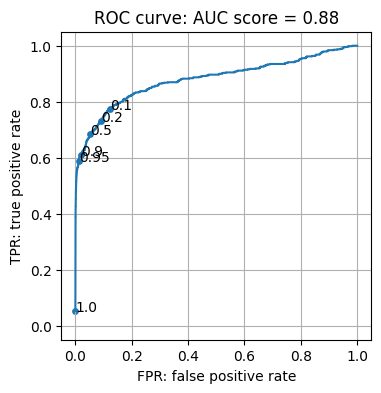

In [37]:
plt.figure(figsize=(4, 4))
plt.plot(roc[0][np.argmin(np.abs(roc[2]-1)):], roc[1][np.argmin(np.abs(roc[2]-1)):])
plt.xlabel('FPR: false positive rate')
plt.ylabel('TPR: true positive rate')
plt.title('ROC curve: AUC score = {:.2f}'.format(auc))

th = [.1, .2, .5, .9, .95, 1.]
ind = [np.argmin(np.abs(roc[2]-l)) for l in th]
plt.scatter(roc[0][ind], roc[1][ind], s=15)
for i, l in enumerate(ind):
    plt.annotate("{}".format(th[i]), xy=(roc[0][l], roc[1][l]))
#plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='black', linewidth=1)
plt.ylim(-.05, 1.05)
plt.xlim(-.05, 1.05)
plt.grid()
#plt.axis('off')
plt.show()

### Seizure detection using the deep learning model
The model predicts seizure existance.  
This detects seizure but does not indicate the seizure onset.  
To find the seizure onsets, peak detection of p is used (distance>6, threshold>=.95).

In [38]:
for i, f in enumerate(files_test):
    if os.path.exists(f+'.seizures'):
        print('Index = {} has seizures: {}'.format(i, f))

Index = 9 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_18.edf
Index = 11 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_26.edf
Index = 12 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf
Index = 20 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_16.edf
Index = 24 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_04.edf
Index = 30 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_21.edf
Index = 37 has seizures: /kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_15.edf
Index = 50 has seizures: /kaggle/in

In [39]:
def moving_ave(a, n):
    if len(a.shape)!=1:
        print('Not 1 dimension array. return nothing.')
        return
    temp = np.zeros(a.size-n)
    for i in range(n):
        temp = temp+a[i:-n+i]
    temp = temp/n
    
    return temp

In [40]:
# get signals and labels from test data.
n=100
array_signals, array_is_sz = sampling_data_pred(files_test[n])

# preprocess
array_signals=array_signals[:, :, ::2, np.newaxis]

# use deep learning model
pred = model.predict(array_signals)

/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb10/chb10_89.edf: Reading. 
57/57 [==============================] - 2s 31ms/step


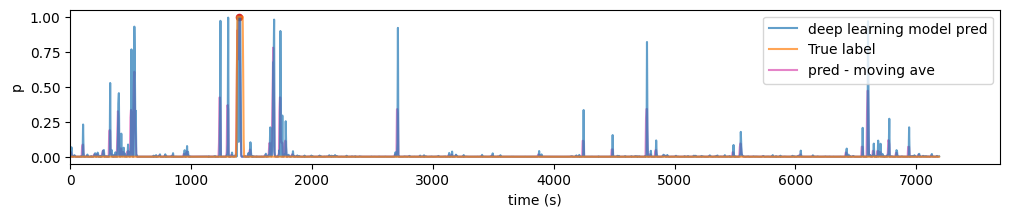

In [41]:
time_window = 8
time_step = 4
mv_win = 3

fig, ax = plt.subplots(figsize=(12, 2))

ax.plot(np.arange(pred.size)*time_step, pred.flatten(), alpha=0.7, label='deep learning model pred')
ax.plot(np.arange(pred.size)*time_step, array_is_sz, alpha=.7, label='True label')

pred_moving_ave = moving_ave(pred.flatten(), mv_win)
pred_peaks, _ = find_peaks(pred_moving_ave, height=.95, distance=6)
ax.plot(np.arange(pred.size-mv_win)*time_step, pred_moving_ave,
        alpha=.9, label='pred - moving ave', color='tab:pink', zorder=0)
ax.scatter(pred_peaks*time_step, pred_moving_ave[pred_peaks], s=20, color='tab:red')

ax.set_xlabel('time (s)')
ax.set_ylabel('p')
ax.set_xlim(0, pred.size*time_step+500)
ax.legend(loc='upper right')
plt.show()



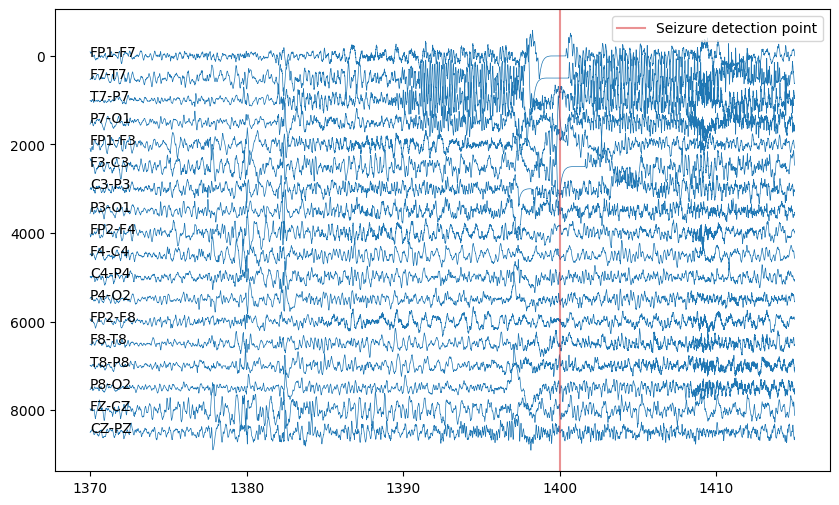

In [42]:
if pred_peaks.size==0:
    print('No seizure detected.')
else:
    f = files_test[n]
    temp_edf =  mne.io.read_raw_edf(f)
    temp_labels = temp_edf.ch_names
    if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
        ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
        temp_edf.rename_channels(ch_mapping)
        #temp_edf = temp_edf.pick(ch_labels)

        temp_is_sz = np.zeros((temp_edf.n_times,))
        temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

    fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
    for n_peak in range(pred_peaks.size):
        ind_peak = pred_peaks[n_peak]*time_step*fs
        backward_steps = 30*fs
        forward_steps = 15*fs
        vertical_width=500

        fig, ax = plt.subplots(figsize=(10, 6))
        for i in range(temp_signals.shape[0]):
            ax.plot(np.arange(ind_peak-backward_steps, ind_peak+forward_steps)/fs,
                    temp_signals[i, ind_peak-backward_steps:ind_peak+forward_steps]+i*vertical_width, linewidth=0.5, color='tab:blue')
            ax.annotate(ch_labels[i], xy=((ind_peak-backward_steps)/fs, i*vertical_width))
        ax.axvline(x=ind_peak/fs, color='tab:red', alpha=0.5, label='Seizure detection point')
        ax.invert_yaxis()
        ax.legend(loc='upper right')
        plt.show()
    #ax.set_xlim(0, 8)

    temp_edf.close()

Data shape: (9505, 18, 1024)
Seizure ratio: 0.272
Training: (6653, 18, 1024, 1), Validation: (2852, 18, 1024, 1)
=== Building Efficient Anti-Overfitting Model ===
Model parameters: 67,857
Model: "Efficient_AntiOverfitting_SeizureDetector"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 eeg_input (InputLayer)      [(None, 18, 1024, 1)]     0         
                                                                 
 random_channel_rearrange (R  (None, 18, 1024, 1)      0         
 andomChannelRearrange)                                          
                                                                 
 random_rescale (RandomResca  (None, 18, 1024, 1)      0         
 le)                                                             
                                                                 
 sep_conv1 (SeparableConv2D)  (None, 18, 1024, 32)     80        
                                   

2025-06-25 15:07:13.174983: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inEfficient_AntiOverfitting_SeizureDetector/dropout1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


104/104 [==============================] - ETA: 0s - loss: 0.6549 - accuracy: 0.6241 - precision: 0.3845 - recall: 0.6324 - f1_score: 0.4699
Epoch 1: val_f1_score improved from -inf to 0.02154, saving model to efficient_model.h5
104/104 [==============================] - 19s 115ms/step - loss: 0.6549 - accuracy: 0.6241 - precision: 0.3845 - recall: 0.6324 - f1_score: 0.4699 - val_loss: 0.6865 - val_accuracy: 0.7167 - val_precision: 0.1407 - val_recall: 0.0120 - val_f1_score: 0.0215 - lr: 0.0020
Epoch 2/30
104/104 [==============================] - ETA: 0s - loss: 0.5961 - accuracy: 0.6705 - precision: 0.4388 - recall: 0.7339 - f1_score: 0.5414
Epoch 2: val_f1_score improved from 0.02154 to 0.30542, saving model to efficient_model.h5
104/104 [==============================] - 11s 105ms/step - loss: 0.5961 - accuracy: 0.6705 - precision: 0.4388 - recall: 0.7339 - f1_score: 0.5414 - val_loss: 0.6933 - val_accuracy: 0.4113 - val_precision: 0.2285 - val_recall: 0.4829 - val_f1_score: 0.3054

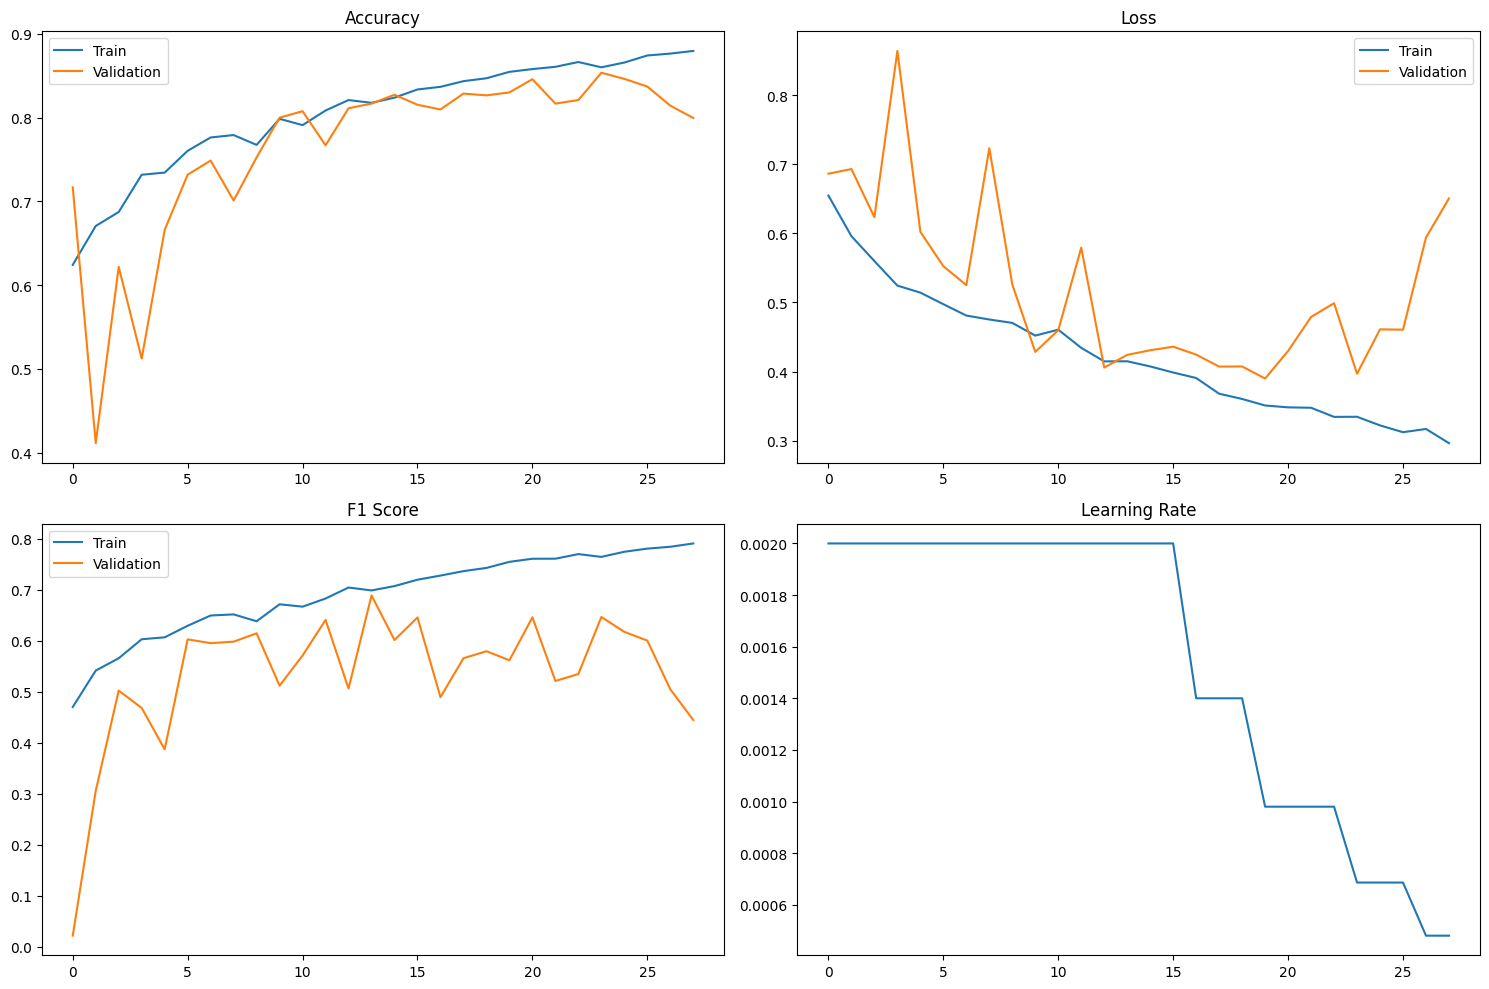

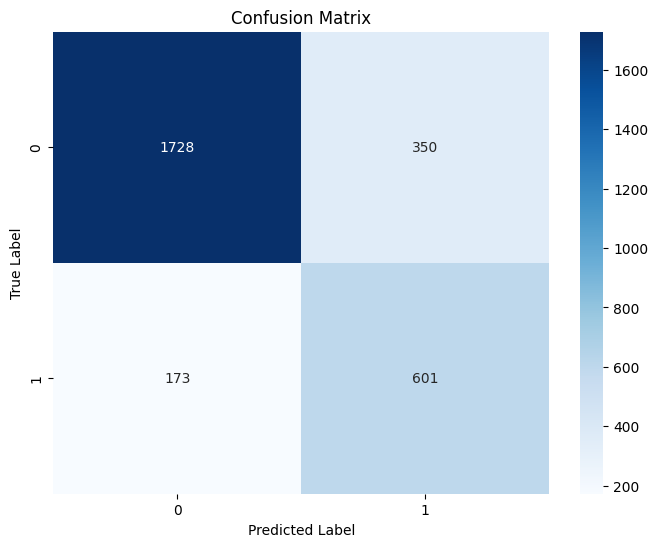

Model saved to seizure_detector_final.h5

=== Training Complete ===
Key improvements:
- Fixed custom metric loading issue
- Added proper serialization decorators
- Random channel rearrangement prevents overfitting
- Random rescaling provides data augmentation
- Depthwise separable convolutions for efficiency
- Aggressive early stopping prevents overfitting

=== Testing Model Loading ===
Model loaded successfully!
Model loading test successful!


In [43]:
# ============ IMPORTS AND SETUP ============
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import gc
import mne
import re
import tqdm
import logging
import os
from scipy.signal import find_peaks
import wfdb
from sklearn import model_selection
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(2023)
np.random.seed(2023)
tf.random.set_seed(2023)

# ============ DATA CONFIGURATION ============
ch_labels = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3','P3-O1',
             'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
             'FZ-CZ', 'CZ-PZ']

# Update this path to your dataset location
path2pt = '/kaggle/input/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0'

# ============ CUSTOM METRICS (FIXED) ============
def create_f1_score():
    """Create F1 score metric function"""
    def f1_score(y_true, y_pred):
        y_pred = tf.round(y_pred)
        tp = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
        fp = tf.reduce_sum(tf.cast((1 - y_true) * y_pred, tf.float32))
        fn = tf.reduce_sum(tf.cast(y_true * (1 - y_pred), tf.float32))
        
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        return 2 * precision * recall / (precision + recall + 1e-8)
    
    return f1_score

def create_precision():
    """Create precision metric function"""
    def precision(y_true, y_pred):
        y_pred = tf.round(y_pred)
        tp = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
        fp = tf.reduce_sum(tf.cast((1 - y_true) * y_pred, tf.float32))
        return tp / (tp + fp + 1e-8)
    
    return precision

def create_recall():
    """Create recall metric function"""
    def recall(y_true, y_pred):
        y_pred = tf.round(y_pred)
        tp = tf.reduce_sum(tf.cast(y_true * y_pred, tf.float32))
        fn = tf.reduce_sum(tf.cast(y_true * (1 - y_pred), tf.float32))
        return tp / (tp + fn + 1e-8)
    
    return recall

# Create metric instances
f1_score = create_f1_score()
precision = create_precision()
recall = create_recall()

# ============ REGULARIZATION LAYERS (FIXED) ============
@keras.saving.register_keras_serializable(package="CustomLayers")
class RandomChannelRearrange(layers.Layer):
    """Random channel rearrangement as regularization technique"""
    def __init__(self, **kwargs):
        super(RandomChannelRearrange, self).__init__(**kwargs)
        
    def call(self, inputs, training=None):
        if training:
            # Randomly shuffle channels during training
            batch_size = tf.shape(inputs)[0]
            n_channels = inputs.shape[1]
            
            # Create random permutation for each sample in batch
            indices = tf.random.shuffle(tf.range(n_channels))
            return tf.gather(inputs, indices, axis=1)
        return inputs
    
    def get_config(self):
        return super().get_config()

@keras.saving.register_keras_serializable(package="CustomLayers")
class RandomRescale(layers.Layer):
    """Random rescaling as regularization technique"""
    def __init__(self, scale_factor=1.5, **kwargs):
        super(RandomRescale, self).__init__(**kwargs)
        self.scale_factor = scale_factor
        
    def call(self, inputs, training=None):
        if training:
            # Random scaling between 1/scale_factor and scale_factor
            scale = tf.random.uniform(
                shape=[tf.shape(inputs)[0], 1, 1, 1],
                minval=1.0/self.scale_factor,
                maxval=self.scale_factor
            )
            return inputs * scale
        return inputs
    
    def get_config(self):
        config = super().get_config()
        config.update({'scale_factor': self.scale_factor})
        return config

# ============ EFFICIENT CNN-LSTM MODEL ============
def build_efficient_antioverfitting_model(input_shape, n_classes=1):
    """
    Efficient CNN-LSTM model with proven anti-overfitting techniques
    """
    
    inputs = keras.Input(shape=input_shape, name='eeg_input')
    
    # ============ REGULARIZATION LAYERS ============
    
    # Random channel rearrangement
    x = RandomChannelRearrange(name='random_channel_rearrange')(inputs)
    
    # Random rescaling
    x = RandomRescale(scale_factor=1.5, name='random_rescale')(x)
    
    # ============ EFFICIENT FEATURE EXTRACTION ============
    
    # Depthwise Separable Convolution Block 1
    x = layers.SeparableConv2D(32, (2, 8), padding='same', activation='relu', name='sep_conv1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling2D((1, 4), name='pool1')(x)
    x = layers.Dropout(0.25, name='dropout1')(x)
    
    # Depthwise Separable Convolution Block 2
    x = layers.SeparableConv2D(64, (2, 4), padding='same', activation='relu', name='sep_conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling2D((1, 2), name='pool2')(x)
    x = layers.Dropout(0.3, name='dropout2')(x)
    
    # Depthwise Separable Convolution Block 3
    x = layers.SeparableConv2D(128, (1, 4), padding='same', activation='relu', name='sep_conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.MaxPooling2D((1, 2), name='pool3')(x)
    x = layers.Dropout(0.3, name='dropout3')(x)
    
    # ============ EFFICIENT TEMPORAL MODELING ============
    
    # Reshape for LSTM
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = layers.RepeatVector(8, name='repeat_vector')(x)
    
    # Single LSTM layer
    x = layers.LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3, name='lstm')(x)
    x = layers.BatchNormalization(name='bn_lstm')(x)
    
    # ============ EFFICIENT CLASSIFICATION ============
    
    # Simplified dense layers
    x = layers.Dense(64, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.4, name='dropout_dense1')(x)
    
    x = layers.Dense(32, activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='dropout_dense2')(x)
    
    # Output layer
    if n_classes == 1:
        outputs = layers.Dense(1, activation='sigmoid', name='seizure_prediction')(x)
        loss = 'binary_crossentropy'
    else:
        outputs = layers.Dense(n_classes, activation='softmax', name='seizure_prediction')(x)
        loss = 'categorical_crossentropy'
    
    model = keras.Model(inputs=inputs, outputs=outputs, name='Efficient_AntiOverfitting_SeizureDetector')
    
    return model, loss

# ============ TRAINING CALLBACKS ============
def create_efficient_callbacks(patience=10):
    """Efficient callbacks with early stopping"""
    
    return [
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.7,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            'efficient_model.h5',
            monitor='val_f1_score',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

# ============ FIXED TRAINING FUNCTION ============
def train_efficient_model(X_train, y_train, X_val, y_val):
    """Train the efficient anti-overfitting model"""
    
    print("=== Building Efficient Anti-Overfitting Model ===")
    
    # Build model
    input_shape = X_train.shape[1:]
    model, loss_fn = build_efficient_antioverfitting_model(input_shape)
    
    # Compile with efficient settings
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.002),
        loss=loss_fn,
        metrics=['accuracy', precision, recall, f1_score]
    )
    
    print(f"Model parameters: {model.count_params():,}")
    model.summary()
    
    # Calculate class weights
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    print(f"Class weights: {weight_dict}")
    
    # Create callbacks
    callbacks = create_efficient_callbacks(patience=8)
    
    # Train model
    print("\n=== Training Efficient Model ===")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=64,
        callbacks=callbacks,
        class_weight=weight_dict,
        verbose=1
    )
    
    # FIXED: Load best model with custom objects
    custom_objects = {
        'RandomChannelRearrange': RandomChannelRearrange,
        'RandomRescale': RandomRescale,
        'f1_score': f1_score,
        'precision': precision,
        'recall': recall
    }
    
    try:
        model = keras.models.load_model('efficient_model.h5', custom_objects=custom_objects)
        print("Model loaded successfully with custom objects")
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Using current model instance instead")
    
    return model, history

# ============ VISUALIZATION FUNCTIONS ============
def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Accuracy
    axes[0, 0].plot(history.history['accuracy'], label='Train')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
    axes[0, 0].set_title('Accuracy')
    axes[0, 0].legend()
    
    # Loss
    axes[0, 1].plot(history.history['loss'], label='Train')
    axes[0, 1].plot(history.history['val_loss'], label='Validation')
    axes[0, 1].set_title('Loss')
    axes[0, 1].legend()
    
    # F1 Score
    if 'f1_score' in history.history:
        axes[1, 0].plot(history.history['f1_score'], label='Train')
        axes[1, 0].plot(history.history['val_f1_score'], label='Validation')
        axes[1, 0].set_title('F1 Score')
        axes[1, 0].legend()
    
    # Learning Rate
    if 'lr' in history.history:
        axes[1, 1].plot(history.history['lr'])
        axes[1, 1].set_title('Learning Rate')
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ============ MAIN EXECUTION WITH FIXED LOADING ============
def main_efficient():
    """Main function using your preprocessed data"""
    
    # Load your preprocessed data
    if os.path.exists('/kaggle/input/mit-chb-processed/signal_samples.npy'):
        array_signals = np.load('/kaggle/input/mit-chb-processed/signal_samples.npy')
        array_is_sz = np.load('/kaggle/input/mit-chb-processed/is_sz.npy')
        
        # Downsample to 128 Hz as in your demo
        array_signals = array_signals[:, :, ::2]
        
    else:
        print("Please run the data preprocessing first or check the file paths")
        return None, None
    
    print(f"Data shape: {array_signals.shape}")
    print(f"Seizure ratio: {np.mean(array_is_sz):.3f}")
    
    # Add channel dimension
    array_signals = array_signals[:, :, :, np.newaxis]
    
    # Split data
    X_train, X_val, y_train, y_val = model_selection.train_test_split(
        array_signals, array_is_sz, 
        test_size=0.3, 
        stratify=array_is_sz,
        random_state=42
    )
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}")
    
    # Train efficient model
    model, history = train_efficient_model(X_train, y_train, X_val, y_val)
    
    # Evaluate
    print("\n=== Evaluation Results ===")
    val_results = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Accuracy: {val_results[1]:.4f}")
    print(f"Validation Precision: {val_results[2]:.4f}")
    print(f"Validation Recall: {val_results[3]:.4f}")
    print(f"Validation F1-Score: {val_results[4]:.4f}")
    
    # Generate predictions
    y_pred_prob = model.predict(X_val)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    # Plot results
    plot_training_history(history)
    plot_confusion_matrix(y_val, y_pred)
    
    return model, history

# ============ UTILITY FUNCTIONS ============
def load_saved_model(model_path='efficient_model.h5'):
    """Utility function to load a saved model with proper custom objects"""
    
    custom_objects = {
        'RandomChannelRearrange': RandomChannelRearrange,
        'RandomRescale': RandomRescale,
        'f1_score': f1_score,
        'precision': precision,
        'recall': recall
    }
    
    try:
        model = keras.models.load_model(model_path, custom_objects=custom_objects)
        print("Model loaded successfully!")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Try loading without compilation for inference only:")
        model = keras.models.load_model(model_path, compile=False)
        return model

def save_model_properly(model, filepath='efficient_model_final.h5'):
    """Save model with proper handling"""
    model.save(filepath)
    print(f"Model saved to {filepath}")

# ============ INFERENCE FUNCTION ============
def predict_seizure(model, eeg_data):
    """Make seizure predictions on new EEG data"""
    if len(eeg_data.shape) == 3:
        eeg_data = eeg_data[np.newaxis, ...]  # Add batch dimension
    
    predictions = model.predict(eeg_data)
    return predictions

# ============ RUN THE FIXED MODEL ============
if __name__ == "__main__":
    model, history = main_efficient()
    
    if model is not None:
        # Save the model properly
        save_model_properly(model, 'seizure_detector_final.h5')
        
        print("\n=== Training Complete ===")
        print("Key improvements:")
        print("- Fixed custom metric loading issue")
        print("- Added proper serialization decorators")
        print("- Random channel rearrangement prevents overfitting")
        print("- Random rescaling provides data augmentation")
        print("- Depthwise separable convolutions for efficiency")
        print("- Aggressive early stopping prevents overfitting")
        
        # Test loading the saved model
        print("\n=== Testing Model Loading ===")
        loaded_model = load_saved_model('seizure_detector_final.h5')
        if loaded_model is not None:
            print("Model loading test successful!")
